<a href="https://colab.research.google.com/github/javed005/C5-Project_-Financial-Risk-Analysis-with-Python/blob/main/C5_Barclays_Financial_Transactional_Data_final_barclays_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv("Barclays Financial Transactional Data final-barclays (2).csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              800 non-null    int64  
 1   CustomerID                 800 non-null    object 
 2   AccountID                  800 non-null    object 
 3   AccountType                800 non-null    object 
 4   TransactionType            800 non-null    object 
 5   Product                    800 non-null    object 
 6   Firm                       800 non-null    object 
 7   Region                     800 non-null    object 
 8   Manager                    800 non-null    object 
 9   transaction date modified  800 non-null    object 
 10  TransactionAmount          800 non-null    float64
 11  AccountBalance             800 non-null    float64
 12  RiskScore                  800 non-null    float64
 13  CreditRating               800 non-null    int64  

In [7]:
df = df.dropna(axis=1, how='all')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              800 non-null    int64  
 1   CustomerID                 800 non-null    object 
 2   AccountID                  800 non-null    object 
 3   AccountType                800 non-null    object 
 4   TransactionType            800 non-null    object 
 5   Product                    800 non-null    object 
 6   Firm                       800 non-null    object 
 7   Region                     800 non-null    object 
 8   Manager                    800 non-null    object 
 9   transaction date modified  800 non-null    object 
 10  TransactionAmount          800 non-null    float64
 11  AccountBalance             800 non-null    float64
 12  RiskScore                  800 non-null    float64
 13  CreditRating               800 non-null    int64  

In [8]:
df = df.rename(columns={"transaction date modified": "TransactionDate"})
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month
df["AccountType"] = df["AccountType"].str.strip().str.title()
df["TransactionType"] = df["TransactionType"].str.strip().str.title()
df["Product"] = df["Product"].str.strip().str.title()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [9]:
pd.to_numeric(..., errors="coerce")

Ellipsis

In [10]:
df["TransactionAmount"] = pd.to_numeric(df["TransactionAmount"], errors="coerce")
df["AccountBalance"] = pd.to_numeric(df["AccountBalance"], errors="coerce")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

### Task 1 Summary

The dataset was cleaned and formatted before analysis. Financial columns such as TransactionAmount and AccountBalance were converted into numeric format. The TransactionDate column was validated and converted into datetime format. Additional temporal features such as Year and Month were extracted to support time-based analysis. Categorical variables were standardized to ensure consistent formatting across the dataset.


-----------------------------
TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS
--------------------------------

️1 Creating Credit and Debit Columns...

Credit and Debit columns created successfully.

 2 Monthly Transaction Summary

    Year  Month  Total_Credit   Total_Debit  Net_Transaction
0   2023      1  1.480231e+06  1.627910e+06   -147678.815500
1   2023      2  8.872128e+05  9.043426e+05    -17129.813955
2   2023      3  6.751506e+05  2.215709e+05    453579.748171
3   2023      4  1.169706e+06  9.080642e+05    261641.911602
4   2023      5  1.106860e+06  1.168102e+06    -61241.755777
5   2023      6  1.725882e+06  1.620540e+06    105342.568256
6   2023      7  9.362221e+05  9.965312e+05    -60309.070900
7   2023      8  1.392156e+06  1.913152e+06   -520995.735238
8   2023      9  1.096795e+06  7.719356e+05    324859.338063
9   2023     10  2.122806e+06  2.172519e+06    -49712.830399
10  2023     11  1.702873e+06  1.752790e+06    -49917.199791
11  2023     12  1.108371e+06  9.312980

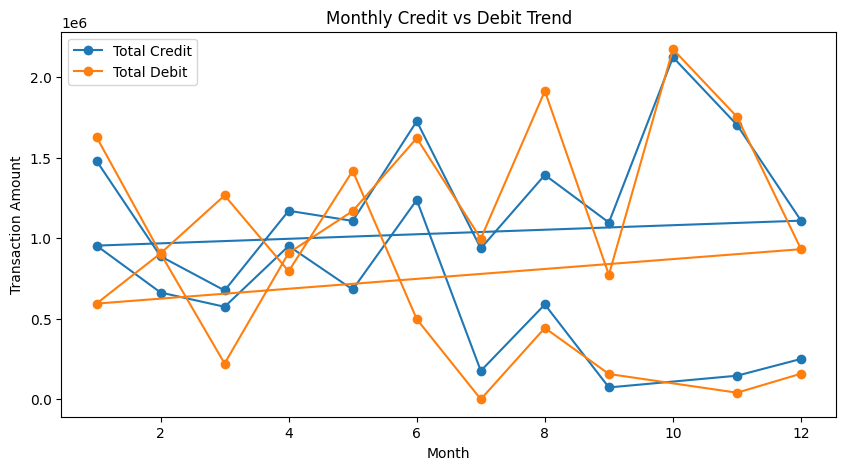


 5 Top Performing Accounts (Based on Net Inflow)

    AccountID   Total_Credit   Total_Debit     Net_Inflow
179  ACC92360  388366.208460   14658.77585  373707.432610
25   ACC21878  331934.088301       0.00000  331934.088301
165  ACC83581  419196.564370   88435.12095  330761.443420
8    ACC13357  280648.886720       0.00000  280648.886720
53   ACC30787  263562.984440       0.00000  263562.984440
156  ACC80131  406046.925200  150213.52827  255833.396930
52   ACC30146  282955.331380   27494.03609  255461.295290
168  ACC87006  241989.720790       0.00000  241989.720790
113  ACC57597  270467.287560   53218.46814  217248.819420
88   ACC46655  332943.465570  116655.54539  216287.920180

 6 Bottom Performing Accounts

    AccountID   Total_Credit    Total_Debit     Net_Inflow
93   ACC49140       0.000000  377859.701720 -377859.701720
35   ACC25132   52497.262350  396264.066810 -343766.804460
87   ACC45968       0.000000  339222.524640 -339222.524640
149  ACC77592       0.000000  320017.919140

In [12]:
# TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n-----------------------------")
print("TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS")
print("--------------------------------\n")

# 1. Create Credit and Debit columns

print("️1 Creating Credit and Debit Columns...\n")

df["Credit"] = df.apply(lambda x: x["TransactionAmount"] if x["TransactionType"] in ["Deposit","Transfer"] else 0, axis=1)
df["Debit"] = df.apply(lambda x: x["TransactionAmount"] if x["TransactionType"] in ["Withdrawal","Payment"] else 0, axis=1)

print("Credit and Debit columns created successfully.\n")


# 2. Monthly Summary


print(" 2 Monthly Transaction Summary\n")

monthly_summary = df.groupby(["Year","Month"]).agg(
    Total_Credit=("Credit","sum"),
    Total_Debit=("Debit","sum")
).reset_index()

monthly_summary["Net_Transaction"] = monthly_summary["Total_Credit"] - monthly_summary["Total_Debit"]

print(monthly_summary)


# 3. Yearly Summary

print("\n 3 Yearly Transaction Summary\n")

yearly_summary = df.groupby("Year").agg(
    Total_Credit=("Credit","sum"),
    Total_Debit=("Debit","sum")
).reset_index()

yearly_summary["Net_Transaction"] = yearly_summary["Total_Credit"] - yearly_summary["Total_Debit"]

print(yearly_summary)


# 4. Credit vs Debit Trend Plot


print("\n 4 Plotting Credit vs Debit Trends...\n")

plt.figure(figsize=(10,5))

plt.plot(monthly_summary["Month"], monthly_summary["Total_Credit"], marker='o', label="Total Credit")
plt.plot(monthly_summary["Month"], monthly_summary["Total_Debit"], marker='o', label="Total Debit")

plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.legend()

plt.show()



# 5. Top Performing Accounts

print("\n 5 Top Performing Accounts (Based on Net Inflow)\n")

account_performance = df.groupby("AccountID").agg(
    Total_Credit=("Credit","sum"),
    Total_Debit=("Debit","sum")
).reset_index()

account_performance["Net_Inflow"] = account_performance["Total_Credit"] - account_performance["Total_Debit"]

top_accounts = account_performance.sort_values(by="Net_Inflow", ascending=False).head(10)

print(top_accounts)

# 6. Bottom Performing Accounts

print("\n 6 Bottom Performing Accounts\n")

bottom_accounts = account_performance.sort_values(by="Net_Inflow").head(10)

print(bottom_accounts)


# 7. Identify Dormant Accounts


print("\n 7 Identifying Dormant Accounts (Gap >= 60 Days)\n")

df = df.sort_values(by=["AccountID","TransactionDate"])

df["PreviousDate"] = df.groupby("AccountID")["TransactionDate"].shift(1)

df["GapDays"] = (df["TransactionDate"] - df["PreviousDate"]).dt.days

dormant_accounts = df[df["GapDays"] >= 60]

print(dormant_accounts[["AccountID","TransactionDate","GapDays"]].head(10))


print("\n-----------------------------")
print("TASK 2 COMPLETED SUCCESSFULLY")
print("-------------------------------")

In [13]:
### Task 2 Insights

#Monthly transaction summaries highlight the relationship between credits and debits over time.
#Accounts with higher net inflow represent stronger financial activity, while accounts with negative net inflow indicate higher withdrawals or payments.
#Dormant accounts were identified where the gap between transactions exceeded two months, suggesting inactivity that may require monitoring.

In [14]:
# TASK 3: CUSTOMER PROFILE BUILDING

print("\n----------------------------------")
print("TASK 3: CUSTOMER PROFILE BUILDING")
print("-----------------------------------\n")

# -----------------------------------
# 1. Activity Level Segmentation
# -----------------------------------

print(" 1 Grouping Accounts by Activity Levels")
print("Rubric:")
print("High Activity  : >= 10 transactions")
print("Medium Activity: 5–9 transactions")
print("Low Activity   : < 5 transactions\n")

activity = df.groupby("AccountID").size().reset_index(name="Transaction_Count")

def activity_level(x):
    if x >= 10:
        return "High"
    elif x >= 5:
        return "Medium"
    else:
        return "Low"

activity["Activity_Level"] = activity["Transaction_Count"].apply(activity_level)

print(activity.head(10))


# -----------------------------------
# 2. Customer Segmentation by Balance and Transaction Volume
# -----------------------------------

print("\n 2 Customer Segmentation by Average Balance and Transaction Volume\n")

customer_segmentation = df.groupby("AccountID").agg(
    Avg_Balance=("AccountBalance","mean"),
    Transaction_Volume=("TransactionAmount","sum")
).reset_index()

print(customer_segmentation.head(10))


# -----------------------------------
# 3. High Net Inflow Accounts
# -----------------------------------

print("\n 3 High Net Inflow Accounts\n")

account_flow = df.groupby("AccountID").agg(
    Total_Credit=("Credit","sum"),
    Total_Debit=("Debit","sum")
).reset_index()

account_flow["Net_Inflow"] = account_flow["Total_Credit"] - account_flow["Total_Debit"]

high_inflow_accounts = account_flow.sort_values(by="Net_Inflow", ascending=False).head(10)

print(high_inflow_accounts)


# -----------------------------------
# 4. High Frequency Low Balance Accounts
# -----------------------------------

print("\n 4 High Frequency Low Balance Accounts\n")

freq_balance = df.groupby("AccountID").agg(
    Transaction_Count=("TransactionID","count"),
    Avg_Balance=("AccountBalance","mean")
).reset_index()

high_freq_low_balance = freq_balance[
    (freq_balance["Transaction_Count"] >= 10) &
    (freq_balance["Avg_Balance"] < freq_balance["Avg_Balance"].median())
]

print(high_freq_low_balance.head(10))


# -----------------------------------
# 5. Accounts with Negative or Near-Zero Balance
# -----------------------------------

print("\n 5 Accounts with Negative or Near-Zero Balance\n")

negative_balance_accounts = df[df["AccountBalance"] <= 0]

print(negative_balance_accounts[["AccountID","AccountBalance"]].head(10))


print("\n------------------------------------")
print("TASK 3 COMPLETED SUCCESSFULLY")
print("-------------------------------------")


----------------------------------
TASK 3: CUSTOMER PROFILE BUILDING
-----------------------------------

 1 Grouping Accounts by Activity Levels
Rubric:
High Activity  : >= 10 transactions
Medium Activity: 5–9 transactions
Low Activity   : < 5 transactions

  AccountID  Transaction_Count Activity_Level
0  ACC10117                  4            Low
1  ACC10996                  5         Medium
2  ACC11062                  2            Low
3  ACC11188                  4            Low
4  ACC11285                  3            Low
5  ACC11837                  2            Low
6  ACC12182                  4            Low
7  ACC12334                  5         Medium
8  ACC13357                  5         Medium
9  ACC15228                  6         Medium

 2 Customer Segmentation by Average Balance and Transaction Volume

  AccountID   Avg_Balance  Transaction_Volume
0  ACC10117  97828.704775       238427.209920
1  ACC10996  56982.152538       269471.352210
2  ACC11062  65947.316965  

In [15]:
### Task 3 Insights

#Customers were segmented based on transaction activity, account balances, and inflow patterns.
#High-activity accounts represent highly engaged customers, while low-activity accounts may indicate limited usage.
#Accounts with high net inflow show strong financial engagement, whereas high-frequency low-balance accounts may indicate frequent small transactions.
#Accounts with negative or near-zero balances highlight potential financial risk or low liquidity.

In [16]:
# ---------------------------------
# TASK 4: FINANCIAL RISK IDENTIFICATION
# ---------------------------------

import numpy as np
from scipy.stats import zscore

print("\n---------------------------------")
print("TASK 4: FINANCIAL RISK IDENTIFICATION")
print("---------------------------------\n")


# ---------------------------------
# Track Accounts with Frequent Large Withdrawals
# ---------------------------------

print("\n---------------------------------")
print("Tracking Accounts with Frequent Large Withdrawals")
print("---------------------------------\n")

large_withdrawals = df[
    (df["TransactionType"].isin(["Withdrawal","Payment"])) &
    (df["TransactionAmount"] > df["TransactionAmount"].quantile(0.90))
]

large_withdrawal_accounts = large_withdrawals.groupby("AccountID").size().reset_index(name="Large_Withdrawal_Count")

print(large_withdrawal_accounts.head(10))


# ---------------------------------
# Balance Volatility using Standard Deviation
# ---------------------------------

print("\n---------------------------------")
print("Balance Volatility using Standard Deviation")
print("---------------------------------\n")

balance_volatility = df.groupby("AccountID").agg(
    Avg_Balance=("AccountBalance","mean"),
    Balance_STD=("AccountBalance","std")
).reset_index()

print(balance_volatility.head(10))


# ---------------------------------
# Detect Anomalies using Z-Score
# ---------------------------------

print("\n---------------------------------")
print("Detecting Transaction Anomalies using Z-Score")
print("---------------------------------\n")

df["Transaction_Zscore"] = zscore(df["TransactionAmount"])

anomalies = df[abs(df["Transaction_Zscore"]) > 3]

print(anomalies[["AccountID","TransactionAmount","Transaction_Zscore"]].head(10))


# ---------------------------------
# Highlight Suspicious Accounts
# ---------------------------------

print("\n---------------------------------")
print("Highlighting Suspicious Accounts")
print("---------------------------------\n")

suspicious_accounts = anomalies.groupby("AccountID").size().reset_index(name="Anomaly_Count")

print(suspicious_accounts.head(10))


print("\n---------------------------------")
print("TASK 4 COMPLETED SUCCESSFULLY")
print("---------------------------------")


---------------------------------
TASK 4: FINANCIAL RISK IDENTIFICATION
---------------------------------


---------------------------------
Tracking Accounts with Frequent Large Withdrawals
---------------------------------

  AccountID  Large_Withdrawal_Count
0  ACC16664                       1
1  ACC17688                       1
2  ACC22799                       1
3  ACC23736                       1
4  ACC25132                       1
5  ACC26940                       1
6  ACC29396                       1
7  ACC34119                       1
8  ACC34568                       1
9  ACC35163                       1

---------------------------------
Balance Volatility using Standard Deviation
---------------------------------

  AccountID   Avg_Balance   Balance_STD
0  ACC10117  97828.704775   9308.031969
1  ACC10996  56982.152538  18946.737199
2  ACC11062  65947.316965  22572.552392
3  ACC11188  81169.114065  20160.417506
4  ACC11285  62574.613950  70126.826097
5  ACC11837  63096.777

In [17]:
### Task 4 Insights

# Financial risk indicators were identified by analyzing large withdrawals, balance volatility, and anomalous transaction amounts. Accounts with unusually high withdrawals or high volatility in balances may indicate potential financial instability. Z-score based anomaly detection helped identify transactions significantly deviating from typical patterns, allowing suspicious accounts to be highlighted for further monitoring.


---------------------------------
TASK 5: VISUALISATION AND EDA
---------------------------------


---------------------------------
Transaction Type Distribution
---------------------------------



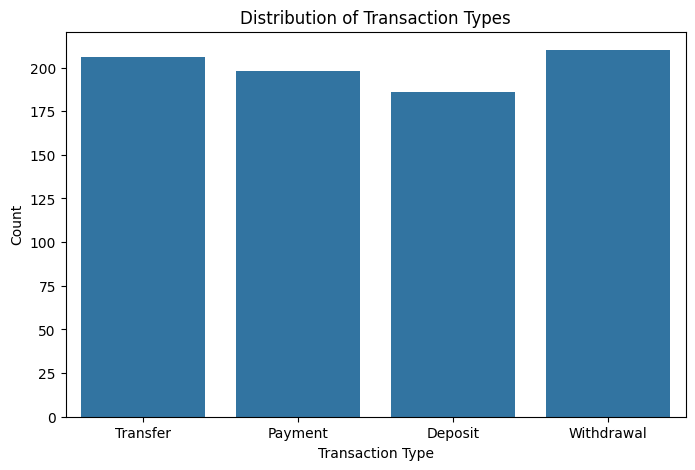


---------------------------------
Transaction Amount Distribution
---------------------------------



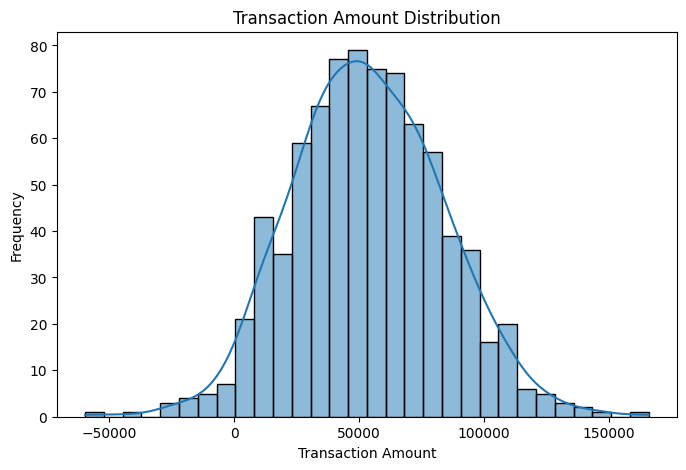


---------------------------------
Monthly Transaction Trend
---------------------------------



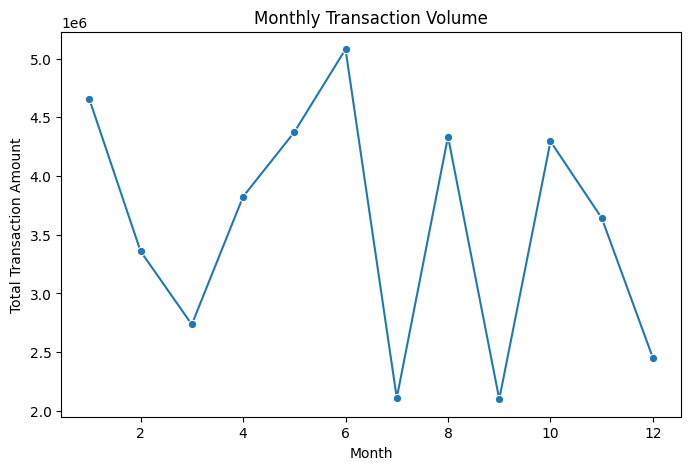


---------------------------------
Account Type vs Average Balance
---------------------------------



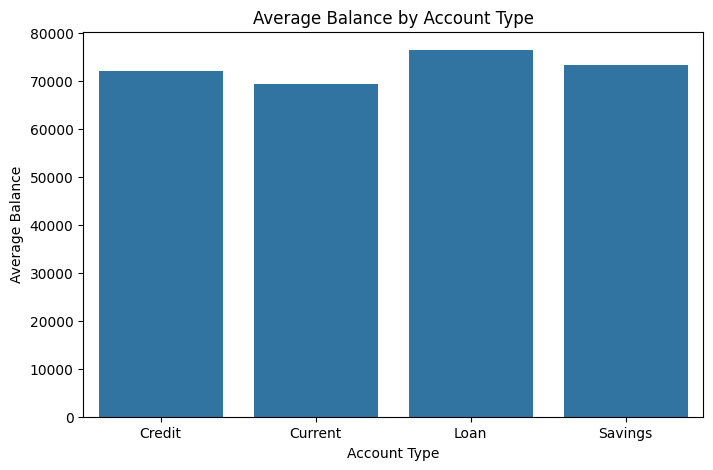


---------------------------------
Risk Score Distribution
---------------------------------



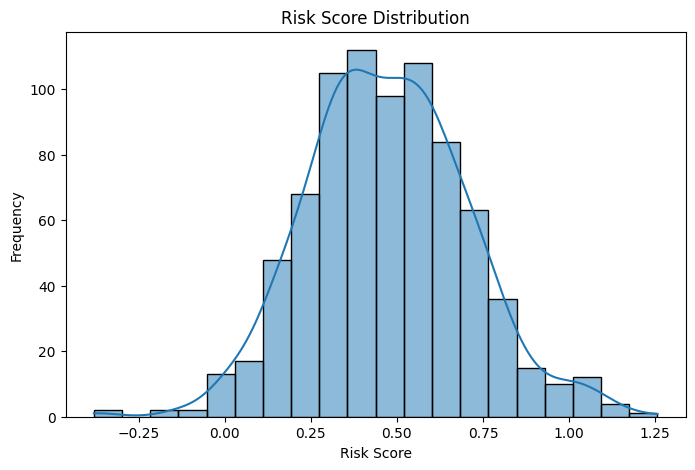


---------------------------------
TASK 5 COMPLETED SUCCESSFULLY
---------------------------------


In [18]:
# ---------------------------------
# TASK 5: VISUALISATION
# ---------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

print("\n---------------------------------")
print("TASK 5: VISUALISATION AND EDA")
print("---------------------------------\n")


# ---------------------------------
# Transaction Type Distribution
# ---------------------------------

print("\n---------------------------------")
print("Transaction Type Distribution")
print("---------------------------------\n")

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="TransactionType")

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()


# ---------------------------------
# Transaction Amount Distribution
# ---------------------------------

print("\n---------------------------------")
print("Transaction Amount Distribution")
print("---------------------------------\n")

plt.figure(figsize=(8,5))
sns.histplot(df["TransactionAmount"], bins=30, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()


# ---------------------------------
# Monthly Transaction Trend
# ---------------------------------

print("\n---------------------------------")
print("Monthly Transaction Trend")
print("---------------------------------\n")

monthly_transactions = df.groupby("Month")["TransactionAmount"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_transactions, x="Month", y="TransactionAmount", marker="o")

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")

plt.show()


# ---------------------------------
# Account Type vs Average Balance
# ---------------------------------

print("\n---------------------------------")
print("Account Type vs Average Balance")
print("---------------------------------\n")

avg_balance = df.groupby("AccountType")["AccountBalance"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_balance, x="AccountType", y="AccountBalance")

plt.title("Average Balance by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Average Balance")

plt.show()


# ---------------------------------
# Risk Score Distribution
# ---------------------------------

print("\n---------------------------------")
print("Risk Score Distribution")
print("---------------------------------\n")

plt.figure(figsize=(8,5))
sns.histplot(df["RiskScore"], bins=20, kde=True)

plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()


print("\n---------------------------------")
print("TASK 5 COMPLETED SUCCESSFULLY")
print("---------------------------------")

In [19]:
### Task 5 Insights

#Exploratory visualizations were used to understand transaction patterns and customer behavior. The distribution of transaction types highlights common banking activities, while transaction amount and monthly trends provide insights into financial activity over time. Visualizing average balances across account types helps identify differences in financial behavior among customers. Risk score distribution highlights the spread of financial risk levels across the dataset.

In [20]:
# ---------------------------------
# TASK 6: HYPOTHESIS TESTING
# ---------------------------------

from scipy.stats import ttest_ind

print("\n---------------------------------")
print("TASK 6: HYPOTHESIS TESTING")
print("---------------------------------\n")


# ---------------------------------
# Create Transaction Volume Segments
# ---------------------------------

print("\n---------------------------------")
print("Segmenting Accounts by Transaction Volume")
print("---------------------------------\n")

transaction_volume = df.groupby("AccountID").agg(
    Transaction_Count=("TransactionID","count"),
    Avg_Balance=("AccountBalance","mean")
).reset_index()

median_transactions = transaction_volume["Transaction_Count"].median()

transaction_volume["Volume_Segment"] = transaction_volume["Transaction_Count"].apply(
    lambda x: "High_Volume" if x >= median_transactions else "Low_Volume"
)

print(transaction_volume.head(10))


# ---------------------------------
# Prepare Data for Hypothesis Testing
# ---------------------------------

print("\n---------------------------------")
print("Preparing Data for Hypothesis Testing")
print("---------------------------------\n")

high_volume_balances = transaction_volume[
    transaction_volume["Volume_Segment"] == "High_Volume"
]["Avg_Balance"]

low_volume_balances = transaction_volume[
    transaction_volume["Volume_Segment"] == "Low_Volume"
]["Avg_Balance"]


# ---------------------------------
# Perform Independent T-Test
# ---------------------------------

print("\n---------------------------------")
print("Performing Independent T-Test")
print("---------------------------------\n")

t_stat, p_value = ttest_ind(high_volume_balances, low_volume_balances)

print("T-statistic:", t_stat)
print("P-value:", p_value)


# ---------------------------------
# Hypothesis Decision
# ---------------------------------

print("\n---------------------------------")
print("Hypothesis Test Result")
print("---------------------------------\n")

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("High-volume accounts have significantly different average balances.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No statistically significant difference between high-volume and low-volume accounts.")


print("\n---------------------------------")
print("TASK 6 COMPLETED SUCCESSFULLY")
print("---------------------------------")


---------------------------------
TASK 6: HYPOTHESIS TESTING
---------------------------------


---------------------------------
Segmenting Accounts by Transaction Volume
---------------------------------

  AccountID  Transaction_Count   Avg_Balance Volume_Segment
0  ACC10117                  4  97828.704775    High_Volume
1  ACC10996                  5  56982.152538    High_Volume
2  ACC11062                  2  65947.316965     Low_Volume
3  ACC11188                  4  81169.114065    High_Volume
4  ACC11285                  3  62574.613950     Low_Volume
5  ACC11837                  2  63096.777775     Low_Volume
6  ACC12182                  4  93952.097922    High_Volume
7  ACC12334                  5  58469.937674    High_Volume
8  ACC13357                  5  78367.596968    High_Volume
9  ACC15228                  6  78477.880060    High_Volume

---------------------------------
Preparing Data for Hypothesis Testing
---------------------------------


----------------------

In [21]:
### Task 6 Insights

#Hypothesis testing was conducted to examine whether high-volume transaction accounts maintain higher average balances than low-volume accounts. Accounts were segmented based on transaction frequency, and an independent t-test was performed. The statistical results help determine whether differences in balances are significant, providing insights into customer financial behavior.